In [ ]:
# ============================================
# IDENTITAS
# Nama  : Arfal Malik Gibran
# NPM   : 24782005
# Kelas : [Kelas]
# ============================================
NAMA = 'Arfal Malik Gibran'
NPM  = '24782005'
my_identity = f'{NAMA} – {NPM}'
print(f'Identitas: {my_identity}')

Identitas: Arfal Malik Gibran – 24782005


## Setup: Load & Eksplorasi Dataset
Dataset **Fashion-MNIST** terdiri dari 60.000 gambar training dan 10.000 gambar test.  
Masing-masing berukuran 28×28 piksel grayscale, dengan 10 kelas.

In [ ]:
import numpy as np

# =====================================================================
# 1. DATASET TABULAR KOMPLEKS (3 Fitur Biner, 5 Sampel)
# =====================================================================
# X1: Ada Mitra, X2: Alat Lolos Uji, X3: Anggaran Realistis
# Y : Status Pendanaan (1=Disetujui, 0=Ditolak)
X = np.array(
    [
        [1, 1, 1],  # Proyek A: Mitra ada, alat siap, budget oke -> SETUJU (1)
        [0, 1, 1],  # Proyek B: Alat siap & budget oke, tapi TANPA MITRA -> TOLAK (0)
        [1, 0, 1],  # Proyek C: Mitra ada & budget oke, tapi ALAT EROR -> TOLAK (0)
        [1, 1, 0],  # Proyek D: Mitra ada & alat siap, tapi OVERBUDGET -> TOLAK (0)
        [1, 0, 0]   # Proyek E: Cuma modal mitra, alat & budget kacau -> TOLAK (0)
    ],
    dtype=float,
)
Y = np.array([1, 0, 0, 0, 0], dtype=float)

# =====================================================================
# 2. ARSITEKTUR JARINGAN (3 Input -> 3 Hidden Neurons -> 1 Output)
# =====================================================================
np.random.seed(7)  # Seed diubah untuk variasi bobot acak baru

# Bobot Hidden Layer: Menghubungkan 3 Input ke 3 Neuron Hidden (H1, H2, H3)
# Matriks berukuran (3 x 3)
W_hidden = np.random.uniform(low=-1.0, high=1.0, size=(3, 3))
B_hidden = np.random.uniform(low=-1.0, high=1.0, size=(3,)) # 3 Bias untuk 3 Neuron Hidden

# Bobot Output Layer: Menghubungkan 3 Neuron Hidden ke 1 Neuron Output
# Array berukuran (3,)
W_output = np.random.uniform(low=-1.0, high=1.0, size=(3,))
B_output = np.random.uniform(low=-1.0, high=1.0, size=(1,))[0] # 1 Bias untuk Output

learning_rate = 0.6
epochs = 100

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    # Turunan ReLU: 1 jika z > 0, selain itu 0
    return np.where(z > 0, 1.0, 0.0)

# =====================================================================
# 3. PROSES PELATIHAN (MURNI STOCHASTIC GRADIENT DESCENT PER SAMPEL)
# =====================================================================
print("=== TRAINING MLP: EVALUASI PROPOSAL PROYEK ===")

print("\n--- Bobot Awal --- ")
print(f"W_hidden:\n{W_hidden}")
print(f"W_output:\n{W_output}")
print(f"B_hidden:\n{B_hidden}")
print(f"B_output:\n{B_output}")

for epoch in range(1, epochs + 1):
    print(f"\n==================== START EPOCH {epoch} ====================")
    epoch_loss = 0

    for i in range(len(X)):
        x_sample = X[i]  # Mengambil 1 baris data (3 fitur), misal: [1, 1, 1]
        y_true = Y[i]  # Target asli (1 atau 0)

        # ---------------------------------------------------------------
        # STEP 1: FEEDFORWARD PROPAGATION (Manual Per Neuron)
        # ---------------------------------------------------------------
        # A. Hitung net input untuk 3 Neuron di Hidden Layer
        net_h1 = (
            (x_sample[0] * W_hidden[0, 0])
            + (x_sample[1] * W_hidden[1, 0])
            + (x_sample[2] * W_hidden[2, 0])
            + B_hidden[0]
        )
        net_h2 = (
            (x_sample[0] * W_hidden[0, 1])
            + (x_sample[1] * W_hidden[1, 1])
            + (x_sample[2] * W_hidden[2, 1])
            + B_hidden[1]
        )
        net_h3 = (
            (x_sample[0] * W_hidden[0, 2])
            + (x_sample[1] * W_hidden[1, 2])
            + (x_sample[2] * W_hidden[2, 2])
            + B_hidden[2]
        )

        # B. Terapkan Fungsi Aktivasi Sigmoid di Hidden Layer
        out_h1 = relu(net_h1)
        out_h2 = relu(net_h2)
        out_h3 = relu(net_h3)

        # C. Hitung net input & output di Output Layer (O1)
        net_output = (
            (out_h1 * W_output[0]) + (out_h2 * W_output[1]) + (out_h3 * W_output[2]) + B_output
        )
        y_pred = sigmoid(net_output)

        # ---------------------------------------------------------------
        # STEP 2: ERROR LOSS CALCULATION
        # ---------------------------------------------------------------
        loss_sample = 0.5 * (y_true - y_pred) ** 2
        epoch_loss += loss_sample

        # ---------------------------------------------------------------
        # STEP 3: BACKPROPAGATION (Menghitung Selisih Eror / Gradien)
        # ---------------------------------------------------------------
        # Delta Output Layer
        error_output_delta = -(y_true - y_pred) * (y_pred * (1 - y_pred))

        # Gradien Bobot Output (W_output)
        grad_W_output0 = error_output_delta * out_h1
        grad_W_output1 = error_output_delta * out_h2
        grad_W_output2 = error_output_delta * out_h3

        # Delta Hidden Layer (Meneruskan error_output_delta ke 3 neuron hidden)
        error_h1_delta = (error_output_delta * W_output[0]) * relu_derivative(net_h1)
        error_h2_delta = (error_output_delta * W_output[1]) * relu_derivative(net_h2)
        error_h3_delta = (error_output_delta * W_output[2]) * relu_derivative(net_h3)

        # ---------------------------------------------------------------
        # STEP 4: STOCHASTIC GRADIENT DESCENT (Update Bobot Langsung)
        # ---------------------------------------------------------------
        # Update Bobot ke Output Layer
        W_output[0] -= learning_rate * grad_W_output0
        W_output[1] -= learning_rate * grad_W_output1
        W_output[2] -= learning_rate * grad_W_output2
        B_output    -= learning_rate * error_output_delta  # FIX: kode asli salah pakai '=='

        # Update Bobot ke Hidden Layer (Matriks 3x3 diupdate satu per satu)
        # Untuk Neuron H1
        W_hidden[0, 0] -= learning_rate * (error_h1_delta * x_sample[0])
        W_hidden[1, 0] -= learning_rate * (error_h1_delta * x_sample[1])
        W_hidden[2, 0] -= learning_rate * (error_h1_delta * x_sample[2])
        B_hidden[0]    -= learning_rate * error_h1_delta

        # Untuk Neuron H2
        W_hidden[0, 1] -= learning_rate * (error_h2_delta * x_sample[0])
        W_hidden[1, 1] -= learning_rate * (error_h2_delta * x_sample[1])
        W_hidden[2, 1] -= learning_rate * (error_h2_delta * x_sample[2])
        B_hidden[1]    -= learning_rate * error_h2_delta

        # Untuk Neuron H3
        W_hidden[0, 2] -= learning_rate * (error_h3_delta * x_sample[0])
        W_hidden[1, 2] -= learning_rate * (error_h3_delta * x_sample[1])
        W_hidden[2, 2] -= learning_rate * (error_h3_delta * x_sample[2])
        B_hidden[2]    -= learning_rate * error_h3_delta

        # Cetak log progress setiap epoch
        print(f"  > Proyek ke-{i+1} [Mtr={int(x_sample[0])}, Alat={int(x_sample[1])}, Bud={int(x_sample[2])}] -> Target={int(y_true)} | Prediksi={y_pred:.4f} | Loss={loss_sample:.4f}")

    print(f"--- Rata-rata Kesalahan Akhir Epoch {epoch}: {epoch_loss / len(X):.6f} ---")
    print("\n--- Bobot setelah Epoch " + str(epoch) + " ---")
    print(f"W_hidden:\n{W_hidden}")
    print(f"W_output:\n{W_output}")
    print(f"B_hidden:\n{B_hidden}")
    print(f"B_output:\n{B_output}")

print("\n============================================================")
print("PROSES TRAINING SELESAI!")
print("============================================================")

# =====================================================================
# 4. PREDIKSI DATA PROPOSAL BARU (INFERENSI)
# =====================================================================
print("\n=== PENGUJIAN PROPOSAL BARU ===")
# Kasus Baru: Proyek F (Ada Mitra = 1, Alat Sudah Siap = 1, Anggaran Realistis = 1)
# Harusnya model memprediksi mendekati angka 1 (Disetujui)
new_proposal = np.array([1, 1, 1], dtype=float)

# Langkah Feedforward untuk data pengujian baru
t_net_h1 = (
    (new_proposal[0] * W_hidden[0, 0])
    + (new_proposal[1] * W_hidden[1, 0])
    + (new_proposal[2] * W_hidden[2, 0])
    + B_hidden[0]
)
t_net_h2 = (
    (new_proposal[0] * W_hidden[0, 1])
    + (new_proposal[1] * W_hidden[1, 1])
    + (new_proposal[2] * W_hidden[2, 1])
    + B_hidden[1]
)
t_net_h3 = (
    (new_proposal[0] * W_hidden[0, 2])
    + (new_proposal[1] * W_hidden[1, 2])
    + (new_proposal[2] * W_hidden[2, 2])
    + B_hidden[2]
)

print(f"  Net H1 (Hidden Neuron 1): {t_net_h1:.4f}")
print(f"  Net H2 (Hidden Neuron 2): {t_net_h2:.4f}")
print(f"  Net H3 (Hidden Neuron 3): {t_net_h3:.4f}")

t_out_h1, t_out_h2, t_out_h3 = relu(t_net_h1), relu(t_net_h2), relu(t_net_h3)

print(f"  Output H1 (Hidden Neuron 1): {t_out_h1:.4f}")
print(f"  Output H2 (Hidden Neuron 2): {t_out_h2:.4f}")
print(f"  Output H3 (Hidden Neuron 3): {t_out_h3:.4f}")

t_net_output = (
    (t_out_h1 * W_output[0]) + (t_out_h2 * W_output[1]) + (t_out_h3 * W_output[2]) + B_output
)
print(f"  Net Output (Output Neuron): {t_net_output:.4f}")

final_prediction = sigmoid(t_net_output)

status_dana = "DISETUJUI (PENDANAN CAIR)" if final_prediction >= 0.5 else "DITOLAK (REVISI/OVERBUDGET)"

print(
    f"Input Proposal Baru : Mitra={int(new_proposal[0])}, Alat Siap={int(new_proposal[1])}, Budget Oke={int(new_proposal[2])}"
)
print(f"Skor Rekomendasi    : {final_prediction:.4f}")
print(f"Keputusan Sistem    : **{status_dana}**")

=== TRAINING MLP: EVALUASI PROPOSAL PROYEK ===

--- Bobot Awal --- 
W_hidden:
[[-0.84738342  0.55983758 -0.12318154]
 [ 0.44693036  0.95597902  0.07699174]
 [ 0.00224093 -0.85589773 -0.46312204]]
W_output:
[-0.23811773 -0.86812731 -0.4237088 ]
B_hidden:
[-2.34998349e-04  3.58459992e-01  6.07478072e-01]
B_output:
0.8191870554392273

==================== START EPOCH 1 ====================
  > Proyek ke-1 [Mtr=1, Alat=1, Bud=1] -> Target=1 | Prediksi=0.4734 | Loss=0.1387
  > Proyek ke-2 [Mtr=0, Alat=1, Bud=1] -> Target=0 | Prediksi=0.6320 | Loss=0.1997
  > Proyek ke-3 [Mtr=1, Alat=0, Bud=1] -> Target=0 | Prediksi=0.6921 | Loss=0.2395
  > Proyek ke-4 [Mtr=1, Alat=1, Bud=0] -> Target=0 | Prediksi=0.2745 | Loss=0.0377
  > Proyek ke-5 [Mtr=1, Alat=0, Bud=0] -> Target=0 | Prediksi=0.4226 | Loss=0.0893
--- Rata-rata Kesalahan Akhir Epoch 1: 0.140969 ---

--- Bobot setelah Epoch 1 ---
W_hidden:
[[-0.84738342  0.57184263 -0.11507433]
 [ 0.46793098  0.98366781  0.09430022]
 [ 0.02324155 -0.8547872

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Load Fashion-MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Label classes
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Normalisasi pixel ke [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten untuk MLP (28x28 -> 784)
X_train_flat = X_train.reshape(-1, 784)
X_test_flat = X_test.reshape(-1, 784)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Jumlah kelas: {len(class_names)}")
print(f"Kelas: {class_names}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set: (60000, 28, 28)
Test set: (10000, 28, 28)
Jumlah kelas: 10
Kelas: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### Tugas Awal: Visualisasi Dataset
Tampilkan **10 sampel gambar acak** dari dataset beserta labelnya dalam satu figure (2 baris × 5 kolom).

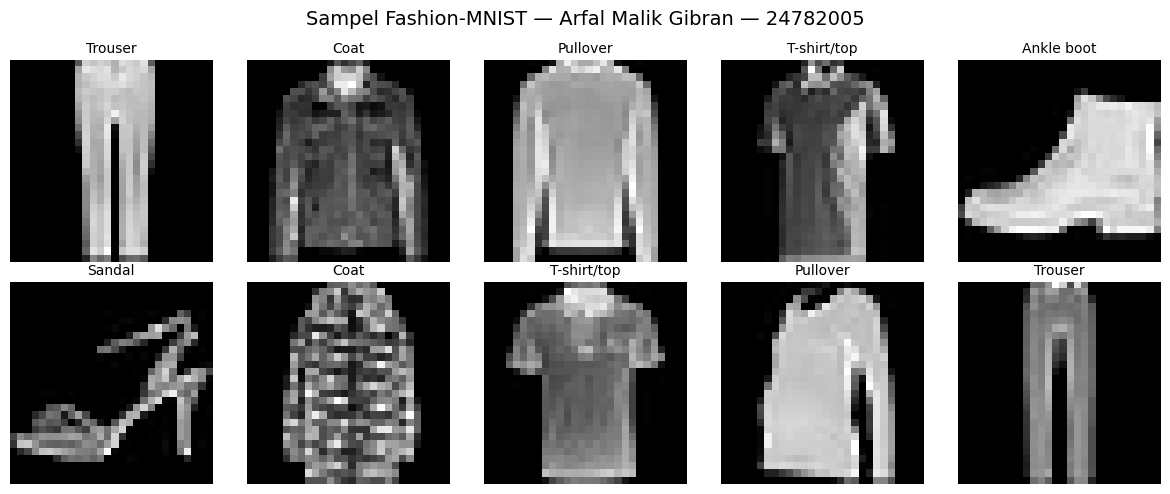

In [4]:
# TODO: Tampilkan 10 gambar acak dari dataset
# Gunakan plt.subplot(2, 5, i+1) untuk layout 2 baris x 5 kolom
# Jangan lupa: plt.title() untuk label, plt.axis('off'), dan identitas di suptitle

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
indices = np.random.choice(len(X_train), 10, replace=False)

for i, idx in enumerate(indices):
    ax = axes[i // 5, i % 5]
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(class_names[y_train[idx]], fontsize=10)
    ax.axis('off')

plt.suptitle(f'Sampel Fashion-MNIST — {NAMA} — {NPM}', fontsize=14)
plt.tight_layout()
plt.show()

---
## 🔬 Eksperimen 1: The Single Neuron — Perceptron from Scratch

**Tujuan:** Memahami mekanisme dasar neuron buatan sebelum menggunakan library.

> *Sebelum Anda menggunakan TensorFlow atau Keras, penting untuk memahami apa yang terjadi di dalam satu neuron. Pada eksperimen ini, Anda akan membuat Perceptron dari nol menggunakan NumPy saja.*

In [6]:
class Perceptron:
    def __init__(self, n_inputs, learning_rate=0.1):
        self.weights = np.zeros(n_inputs)
        self.bias = 0
        self.lr = learning_rate
        self.history = []  # Menyimpan akurasi per epoch

    def activation(self, z):
        """Step function: return 1 if z >= 0, else 0"""
        # TODO: Lengkapi fungsi aktivasi step function
        # Hint: gunakan conditional atau np.where
        return np.where(z >= 0, 1, 0)

    def predict(self, X):
        """Hitung weighted sum lalu terapkan activation"""
        # TODO: Hitung z = X . weights + bias
        # Lalu return self.activation(z)
        z = np.dot(X, self.weights) + self.bias
        return self.activation(z)

    def train(self, X, y, epochs=20):
        """Latih Perceptron menggunakan Perceptron Learning Rule"""
        for epoch in range(epochs):
            correct = 0
            for xi, yi in zip(X, y):
                pred = self.predict(xi)
                error = yi - pred

                # TODO: Update weights dan bias
                # Perceptron Learning Rule: w = w + lr * error * x
                self.weights += self.lr * error * xi
                self.bias    += self.lr * error

                if pred == yi:
                    correct += 1
            acc = correct / len(y)
            self.history.append(acc)
        return self.history

In [7]:
# Dataset Logic Gates
X_and = np.array([[0,0], [0,1], [1,0], [1,1]])
y_and = np.array([0, 0, 0, 1])

X_or = np.array([[0,0], [0,1], [1,0], [1,1]])
y_or = np.array([0, 1, 1, 1])

X_xor = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xor = np.array([0, 1, 1, 0])

print("Datasets siap!")

Datasets siap!


In [8]:
def plot_decision_boundary_perceptron(perceptron, X, y, title="Decision Boundary"):
    """Visualisasi decision boundary untuk Perceptron pada data 2D"""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = np.array([perceptron.predict(point) for point in grid])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    plt.scatter(X[y==0, 0], X[y==0, 1], c='red', marker='o', s=100, edgecolors='k', label='Kelas 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', marker='s', s=100, edgecolors='k', label='Kelas 1')
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.grid(True, alpha=0.3)


AND Gate
  Input: [0 0] | Target: 0 | Prediksi: 0 | ✓
  Input: [0 1] | Target: 0 | Prediksi: 0 | ✓
  Input: [1 0] | Target: 0 | Prediksi: 0 | ✓
  Input: [1 1] | Target: 1 | Prediksi: 1 | ✓
  Akurasi Akhir: 100%

OR Gate
  Input: [0 0] | Target: 0 | Prediksi: 0 | ✓
  Input: [0 1] | Target: 1 | Prediksi: 1 | ✓
  Input: [1 0] | Target: 1 | Prediksi: 1 | ✓
  Input: [1 1] | Target: 1 | Prediksi: 1 | ✓
  Akurasi Akhir: 100%

XOR Gate
  Input: [0 0] | Target: 0 | Prediksi: 1 | ✗
  Input: [0 1] | Target: 1 | Prediksi: 1 | ✓
  Input: [1 0] | Target: 1 | Prediksi: 0 | ✗
  Input: [1 1] | Target: 0 | Prediksi: 0 | ✓
  Akurasi Akhir: 0%


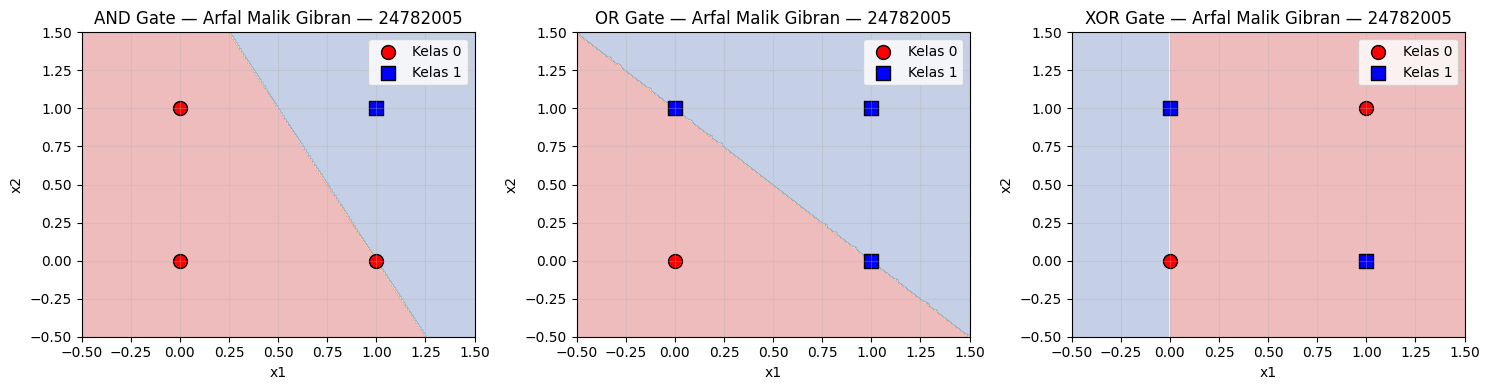

In [9]:
# Latih Perceptron pada AND, OR, dan XOR
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

gates = [
    ('AND Gate', X_and, y_and),
    ('OR Gate', X_or, y_or),
    ('XOR Gate', X_xor, y_xor)
]

for i, (name, X, y) in enumerate(gates):
    p = Perceptron(n_inputs=2, learning_rate=0.1)
    history = p.train(X, y, epochs=20)

    # Print hasil prediksi
    print(f"\n{'='*30}")
    print(f"{name}")
    print(f"{'='*30}")
    for xi, yi in zip(X, y):
        pred = p.predict(xi)
        status = '✓' if pred == yi else '✗'
        print(f"  Input: {xi} | Target: {yi} | Prediksi: {pred} | {status}")
    print(f"  Akurasi Akhir: {history[-1]*100:.0f}%")

    # Plot decision boundary
    plt.sca(axes[i])
    plot_decision_boundary_perceptron(p, X, y, f"{name} — {NAMA} — {NPM}")

plt.tight_layout()
plt.show()

---
## 🔬 Eksperimen 2: Breaking the Barrier — Multi-Layer Perceptron

**Tujuan:** Memahami bagaimana hidden layer mengatasi limitasi Perceptron tunggal.

> *Perceptron gagal di XOR karena hanya bisa membuat satu garis lurus. Bagaimana jika kita menumpuk beberapa neuron? Inilah ide dari **Multi-Layer Perceptron (MLP)** — arsitektur yang menjadi cikal bakal Deep Learning.*

In [10]:
# 2A. MLP Menyelesaikan XOR

model_xor = Sequential([
    Dense(4, activation='relu', input_shape=(2,)),
    Dense(1, activation='sigmoid')
])

model_xor.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_xor = model_xor.fit(X_xor, y_xor, epochs=500, verbose=0)

# Verifikasi hasil
print("Hasil MLP pada XOR:")
for xi, yi in zip(X_xor, y_xor):
    pred = (model_xor.predict(xi.reshape(1, -1), verbose=0) > 0.5).astype(int)[0][0]
    status = '✓' if pred == yi else '✗'
    print(f"  Input: {xi} | Target: {yi} | Prediksi: {pred} | {status}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Hasil MLP pada XOR:
  Input: [0 0] | Target: 0 | Prediksi: 1 | ✗
  Input: [0 1] | Target: 1 | Prediksi: 1 | ✓
  Input: [1 0] | Target: 1 | Prediksi: 1 | ✓
  Input: [1 1] | Target: 0 | Prediksi: 0 | ✓


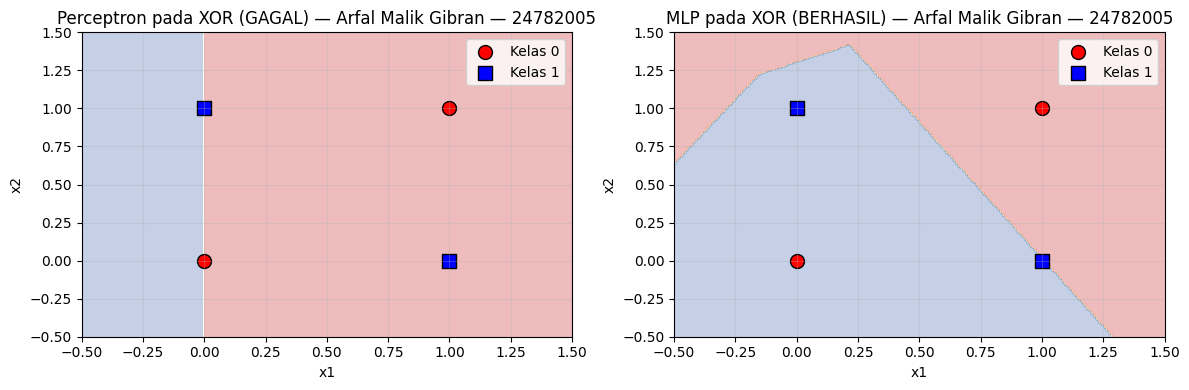

In [11]:
# Visualisasi: MLP vs Perceptron pada XOR
def plot_decision_boundary_keras(model, X, y, title='Decision Boundary'):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = (model.predict(grid, verbose=0) > 0.5).astype(int).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    plt.scatter(X[y==0, 0], X[y==0, 1], c='red', marker='o', s=100, edgecolors='k', label='Kelas 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', marker='s', s=100, edgecolors='k', label='Kelas 1')
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Perceptron pada XOR (gagal)
plt.sca(axes[0])
p_xor = Perceptron(n_inputs=2)
p_xor.train(X_xor, y_xor, epochs=20)
plot_decision_boundary_perceptron(p_xor, X_xor, y_xor, f'Perceptron pada XOR (GAGAL) — {NAMA} — {NPM}')

# MLP pada XOR (berhasil)
plt.sca(axes[1])
plot_decision_boundary_keras(model_xor, X_xor, y_xor, f'MLP pada XOR (BERHASIL) — {NAMA} — {NPM}')

plt.tight_layout()
plt.show()

In [12]:
# 2B. MLP sederhana untuk Fashion-MNIST

model_simple = Sequential([
    Dense(64, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])

model_simple.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

history = model_simple.fit(X_train_flat, y_train, epochs=10,
                           validation_split=0.2, verbose=1)

# Evaluasi
test_loss, test_acc = model_simple.evaluate(X_test_flat, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8115 - loss: 0.5400 - val_accuracy: 0.8378 - val_loss: 0.4554
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8570 - loss: 0.4054 - val_accuracy: 0.8588 - val_loss: 0.4091
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8679 - loss: 0.3646 - val_accuracy: 0.8627 - val_loss: 0.3838
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8774 - loss: 0.3408 - val_accuracy: 0.8662 - val_loss: 0.3739
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8817 - loss: 0.3225 - val_accuracy: 0.8790 - val_loss: 0.3403
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8899 - loss: 0.3052 - val_accuracy: 0.8781 - val_loss: 0.3390
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8920 - loss: 0.2935 - val_accuracy: 0.8759 - val_loss: 0.3571
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8960 - loss: 0.2826 -

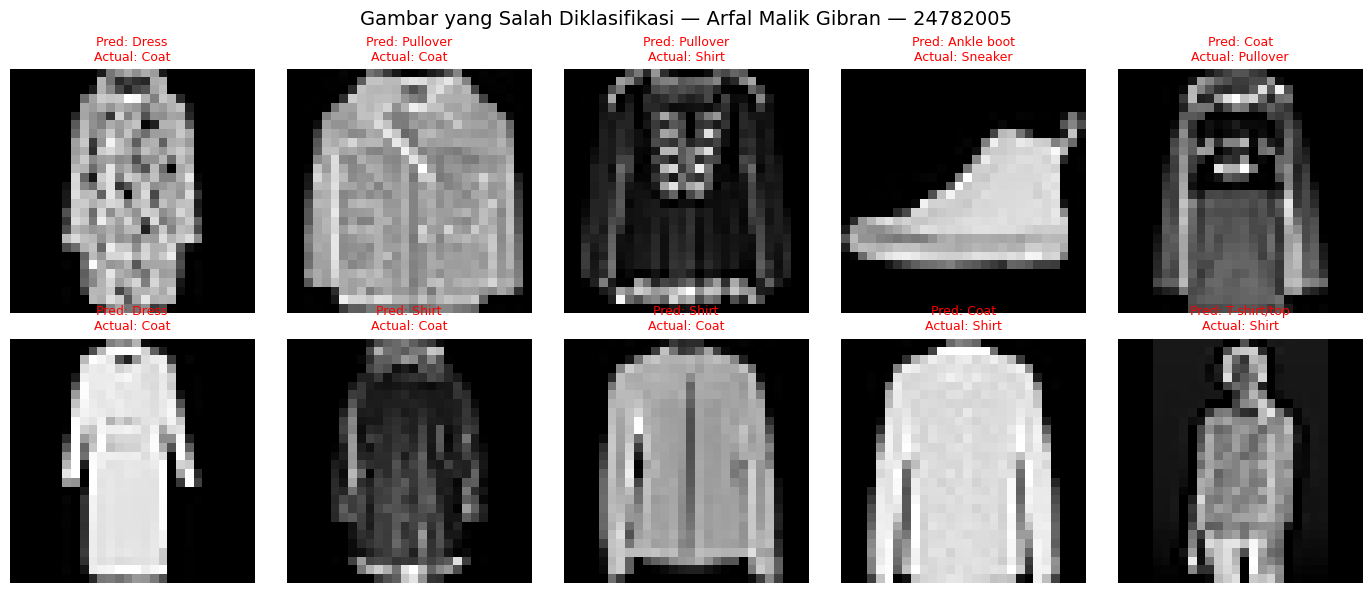

In [13]:
# Tampilkan 10 gambar yang SALAH diklasifikasi
y_pred = model_simple.predict(X_test_flat, verbose=0).argmax(axis=1)
misclassified_idx = np.where(y_pred != y_test)[0]
selected = np.random.choice(misclassified_idx, min(10, len(misclassified_idx)), replace=False)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, idx in enumerate(selected):
    ax = axes[i // 5, i % 5]
    ax.imshow(X_test[idx], cmap='gray')
    ax.set_title(f'Pred: {class_names[y_pred[idx]]}\nActual: {class_names[y_test[idx]]}',
                 color='red', fontsize=9)
    ax.axis('off')

plt.suptitle(f'Gambar yang Salah Diklasifikasi — {NAMA} — {NPM}', fontsize=14)
plt.tight_layout()
plt.show()

---
## 🔬 Eksperimen 3: The Tuning Game — Hyperparameter Sensitivity

**Tujuan:** Menganalisis dampak setiap hyperparameter terhadap proses pembelajaran Neural Network.

> *Neural Network memiliki banyak "kenop" yang bisa diputar. Pada eksperimen ini, Anda akan membuktikan sendiri bahwa pemilihan hyperparameter bukan tebak-tebakan — setiap perubahan memiliki dampak yang bisa diprediksi secara logis.*

Gunakan Fashion-MNIST. Untuk setiap sub-eksperimen, ubah **hanya satu variabel** sementara yang lain tetap (*control experiment*).

In [14]:
# Eksperimen 3A: Variasi jumlah neuron
neuron_configs = [8, 32, 128, 512]
results_3a = []

for n_neurons in neuron_configs:
    print(f'\nTraining dengan {n_neurons} neuron...')
    model = Sequential([
        Dense(n_neurons, activation='relu', input_shape=(784,)),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    start = time.time()
    model.fit(X_train_flat, y_train, epochs=10, validation_split=0.2, verbose=0)
    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(X_test_flat, y_test, verbose=0)
    results_3a.append({'neurons': n_neurons, 'test_acc': test_acc, 'time': elapsed})
    print(f'  -> Test Acc: {test_acc*100:.2f}% | Waktu: {elapsed:.1f}s')

# Tampilkan tabel
print('\n' + '='*55)
print(f'Eksperimen 3A: Variasi Jumlah Neuron — {NAMA} — {NPM}')
print('='*55)
print(f'{"Neuron":>10} | {"Test Accuracy":>15} | {"Training Time":>15}')
print('-'*55)
for r in results_3a:
    print(f'{r["neurons"]:>10} | {r["test_acc"]*100:>14.2f}% | {r["time"]:>13.1f}s')
print('='*55)


Training dengan 8 neuron...
  -> Test Acc: 84.05% | Waktu: 37.8s

Training dengan 32 neuron...
  -> Test Acc: 87.07% | Waktu: 42.0s

Training dengan 128 neuron...
  -> Test Acc: 87.72% | Waktu: 70.1s

Training dengan 512 neuron...
  -> Test Acc: 88.23% | Waktu: 128.4s

Eksperimen 3A: Variasi Jumlah Neuron — Arfal Malik Gibran — 24782005
    Neuron |   Test Accuracy |   Training Time
-------------------------------------------------------
         8 |          84.05% |          37.8s
        32 |          87.07% |          42.0s
       128 |          87.72% |          70.1s
       512 |          88.23% |         128.4s


In [15]:
# Eksperimen 3B: Variasi jumlah hidden layer
layer_configs = [1, 2, 4, 8]
results_3b = []

for n_layers in layer_configs:
    print(f'\nTraining dengan {n_layers} hidden layer(s)...')
    model = Sequential()
    model.add(Dense(64, activation='relu', input_shape=(784,)))
    for _ in range(n_layers - 1):
        model.add(Dense(64, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    start = time.time()
    model.fit(X_train_flat, y_train, epochs=10, validation_split=0.2, verbose=0)
    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(X_test_flat, y_test, verbose=0)
    results_3b.append({'layers': n_layers, 'test_acc': test_acc, 'time': elapsed})
    print(f'  -> Test Acc: {test_acc*100:.2f}% | Waktu: {elapsed:.1f}s')

# Tampilkan tabel
print('\n' + '='*55)
print(f'Eksperimen 3B: Variasi Jumlah Hidden Layer — {NAMA} — {NPM}')
print('='*55)
print(f'{"Layers":>10} | {"Test Accuracy":>15} | {"Training Time":>15}')
print('-'*55)
for r in results_3b:
    print(f'{r["layers"]:>10} | {r["test_acc"]*100:>14.2f}% | {r["time"]:>13.1f}s')
print('='*55)


Training dengan 1 hidden layer(s)...
  -> Test Acc: 86.54% | Waktu: 49.8s

Training dengan 2 hidden layer(s)...
  -> Test Acc: 87.37% | Waktu: 51.8s

Training dengan 4 hidden layer(s)...
  -> Test Acc: 87.86% | Waktu: 58.8s

Training dengan 8 hidden layer(s)...
  -> Test Acc: 86.74% | Waktu: 68.0s

Eksperimen 3B: Variasi Jumlah Hidden Layer — Arfal Malik Gibran — 24782005
    Layers |   Test Accuracy |   Training Time
-------------------------------------------------------
         1 |          86.54% |          49.8s
         2 |          87.37% |          51.8s
         4 |          87.86% |          58.8s
         8 |          86.74% |          68.0s



Training dengan learning rate = 0.0001...
  -> Test Acc: 86.43%

Training dengan learning rate = 0.001...
  -> Test Acc: 88.10%

Training dengan learning rate = 0.01...
  -> Test Acc: 81.26%

Training dengan learning rate = 0.1...
  -> Test Acc: 22.29%


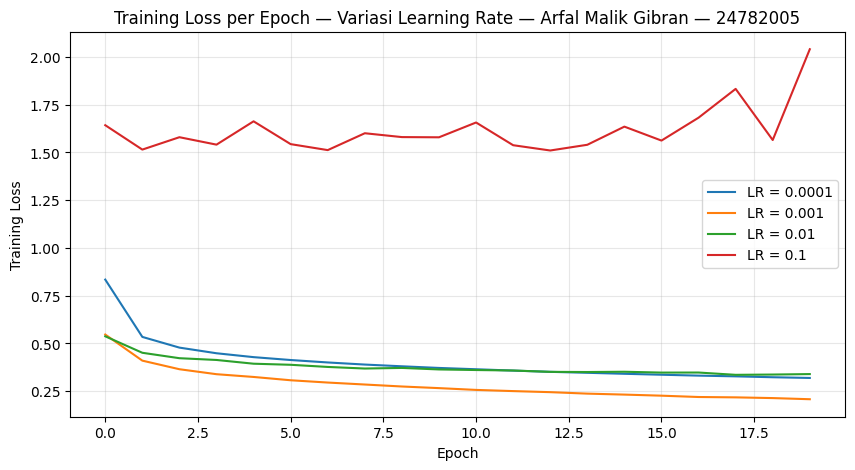


Eksperimen 3C: Variasi Learning Rate — Arfal Malik Gibran — 24782005
  Learning Rate |   Test Accuracy
---------------------------------------------
         0.0001 |          86.43%
          0.001 |          88.10%
           0.01 |          81.26%
            0.1 |          22.29%


In [16]:
# Eksperimen 3C: Variasi learning rate
learning_rates = [0.0001, 0.001, 0.01, 0.1]
results_3c = []
histories_3c = {}

for lr in learning_rates:
    print(f'\nTraining dengan learning rate = {lr}...')
    model = Sequential([
        Dense(64, activation='relu', input_shape=(784,)),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    history = model.fit(X_train_flat, y_train, epochs=20,
                        validation_split=0.2, verbose=0)
    histories_3c[lr] = history.history['loss']
    test_loss, test_acc = model.evaluate(X_test_flat, y_test, verbose=0)
    results_3c.append({'lr': lr, 'test_acc': test_acc})
    print(f'  -> Test Acc: {test_acc*100:.2f}%')

# Plot kurva Training Loss per Epoch untuk 4 LR dalam 1 grafik
plt.figure(figsize=(10, 5))
for lr, losses in histories_3c.items():
    plt.plot(losses, label=f'LR = {lr}')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title(f'Training Loss per Epoch — Variasi Learning Rate — {NAMA} — {NPM}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Tabel
print('\n' + '='*45)
print(f'Eksperimen 3C: Variasi Learning Rate — {NAMA} — {NPM}')
print('='*45)
print(f'{"Learning Rate":>15} | {"Test Accuracy":>15}')
print('-'*45)
for r in results_3c:
    print(f'{r["lr"]:>15} | {r["test_acc"]*100:>14.2f}%')
print('='*45)

In [18]:
# Eksperimen 3D: Variasi activation function
activations = ['sigmoid', 'tanh', 'relu']
results_3d = []

for act in activations:
    print(f"\nTraining dengan activation = '{act}'...")
    model = Sequential([
        Dense(64, activation=act, input_shape=(784,)),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    start = time.time()
    model.fit(X_train_flat, y_train, epochs=10, validation_split=0.2, verbose=0)
    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(X_test_flat, y_test, verbose=0)
    results_3d.append({'activation': act, 'test_acc': test_acc, 'time': elapsed})
    print(f'  -> Test Acc: {test_acc*100:.2f}% | Waktu: {elapsed:.1f}s')

# Tabel
print('\n' + '='*55)
print(f'Eksperimen 3D: Variasi Activation Function — {NAMA} — {NPM}')
print('='*55)
print(f'{"Activation":>12} | {"Test Accuracy":>15} | {"Training Time":>15}')
print('-'*55)
for r in results_3d:
    print(f'{r["activation"]:>12} | {r["test_acc"]*100:>14.2f}% | {r["time"]:>13.1f}s')
print('='*55)


Training dengan activation = 'sigmoid'...
  -> Test Acc: 87.21% | Waktu: 49.1s

Training dengan activation = 'tanh'...
  -> Test Acc: 87.52% | Waktu: 49.2s

Training dengan activation = 'relu'...
  -> Test Acc: 87.14% | Waktu: 49.1s

Eksperimen 3D: Variasi Activation Function — Arfal Malik Gibran — 24782005
  Activation |   Test Accuracy |   Training Time
-------------------------------------------------------
     sigmoid |          87.21% |          49.1s
        tanh |          87.52% |          49.2s
        relu |          87.14% |          49.1s


---
## 🔬 Eksperimen 4: When More is Less — Overfitting Diagnosis (TAKE-HOME)

**Tujuan:** Mendiagnosis overfitting dan menerapkan teknik regularisasi khas Neural Network.

> *Di Lab 7, Anda pernah melihat k-NN dengan k=1 mendapat akurasi 100% pada training set tapi buruk di test set. Fenomena yang sama terjadi pada Neural Network — dan solusinya lebih canggih: **Dropout** dan **Early Stopping**.*

In [19]:
# Model A: Sederhana (baseline)
print("Training Model A (Simple)...")
model_A = Sequential([
    Dense(64, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])
model_A.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_A = model_A.fit(X_train_flat, y_train, epochs=50,
                        validation_split=0.2, verbose=0)
print("Model A selesai!")

Training Model A (Simple)...
Model A selesai!


In [21]:
# Model B: Kompleks TANPA regularisasi
print("Training Model B (Complex, no regularization)...")
model_B = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model_B.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_B = model_B.fit(X_train_flat, y_train, epochs=50,
                        validation_split=0.2, verbose=0)
print("Model B selesai!")

Training Model B (Complex, no regularization)...
Model B selesai!


In [22]:
# Model C: Kompleks DENGAN Dropout + Early Stopping
print("Training Model C (Complex + Dropout + Early Stopping)...")
model_C = Sequential([
    Dense(512, activation='relu', input_shape=(784,)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])
model_C.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_C = model_C.fit(X_train_flat, y_train, epochs=50,
                        validation_split=0.2, verbose=0,
                        callbacks=[early_stop])
print(f"Model C selesai! (Berhenti di epoch {len(history_C.history['loss'])})")

Training Model C (Complex + Dropout + Early Stopping)...
Model C selesai! (Berhenti di epoch 9)


In [ ]:
# Plot Training vs Validation Loss untuk ketiga model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_info = [
    ('Model A (Simple)', history_A),
    ('Model B (Complex, No Reg)', history_B),
    ('Model C (Complex + Dropout)', history_C)
]

for i, (name, hist) in enumerate(models_info):
    axes[i].plot(hist.history['loss'], label='Training Loss', linewidth=2)
    axes[i].plot(hist.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[i].set_title(f'{name} — {NAMA} — {NPM}', fontsize=11)
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# Tabel Perbandingan Performa
print("\n" + "="*75)
print(f"{'Model':<30} | {'Train Acc':>10} | {'Test Acc':>10} | {'Gap':>8}")
print("-"*75)

for name, model, hist in [('A (Simple)', model_A, history_A),
                           ('B (Complex, No Reg)', model_B, history_B),
                           ('C (Complex + Dropout)', model_C, history_C)]:
    train_acc = hist.history['accuracy'][-1]
    test_loss, test_acc = model.evaluate(X_test_flat, y_test, verbose=0)
    gap = train_acc - test_acc
    print(f"{name:<30} | {train_acc*100:>9.2f}% | {test_acc*100:>9.2f}% | {gap*100:>7.2f}%")

print("="*75)


Model                          |  Train Acc |   Test Acc |      Gap
---------------------------------------------------------------------------
A (Simple)                     |     95.43% |     88.14% |    7.29%
B (Complex, No Reg)            |     96.71% |     88.85% |    7.86%
C (Complex + Dropout)          |     87.55% |     86.73% |    0.82%


---
## 🔬 Eksperimen 5: Refleksi — Neural Network dalam Konteks AI Pipeline

**Tujuan:** Menghubungkan Neural Network dengan seluruh perjalanan belajar dari Lab 1 hingga Lab 10.

> *Anda telah melewati perjalanan panjang: dari rule-based agent (Lab 1), ke search algorithms (Lab 3), ke Machine Learning klasik (Lab 5-7), lalu ke Computer Vision (Lab 9) dan NLP (Lab 10). Sekarang saatnya melihat ke belakang dan ke depan.*

### 5A. Prediksi Salah yang "Manusiawi"
Gunakan **model terbaik** dari Eksperimen 4 untuk analisis berikut.

<Figure size 1000x800 with 0 Axes>

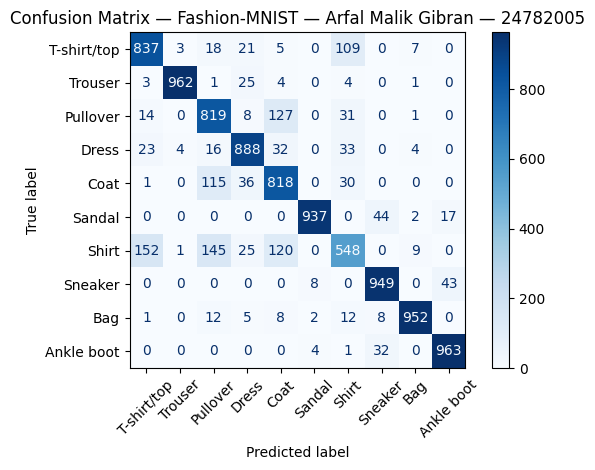

In [25]:
# TODO: Pilih model terbaik dari Eksperimen 4 (ganti model_X sesuai hasil Anda)
best_model = model_C  # Ganti jika model lain lebih baik

# Confusion Matrix
y_pred_best = best_model.predict(X_test_flat, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title(f'Confusion Matrix — Fashion-MNIST — {NAMA} — {NPM}')
plt.tight_layout()
plt.show()

In [26]:
# Identifikasi 3 pasangan kelas yang paling sering tertukar
# Cari off-diagonal values terbesar di confusion matrix
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

print("Top 3 Pasangan Kelas yang Paling Sering Tertukar:")
print("="*60)
for rank in range(3):
    idx = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
    true_class = class_names[idx[0]]
    pred_class = class_names[idx[1]]
    count = cm_no_diag[idx]
    print(f"  {rank+1}. {true_class} -> salah diprediksi sebagai {pred_class} ({count} kali)")
    cm_no_diag[idx] = 0  # Remove to find next

Top 3 Pasangan Kelas yang Paling Sering Tertukar:
  1. Shirt -> salah diprediksi sebagai T-shirt/top (152 kali)
  2. Shirt -> salah diprediksi sebagai Pullover (145 kali)
  3. Pullover -> salah diprediksi sebagai Coat (127 kali)


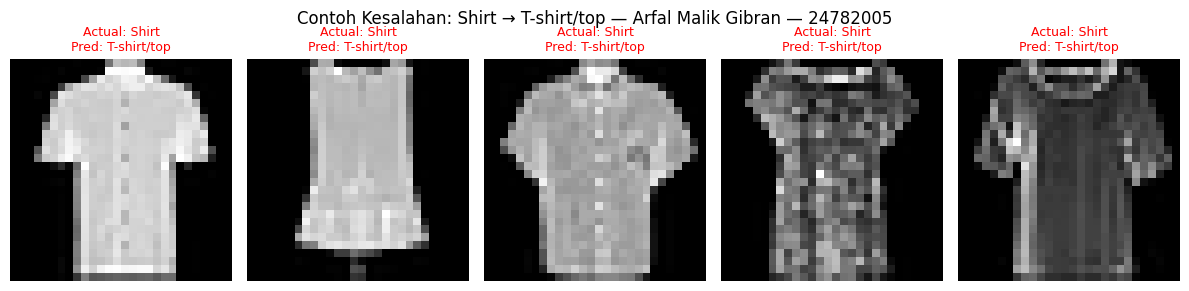

In [27]:
# TODO: Tampilkan 5 sampel gambar untuk salah satu pasangan yang tertukar
# Pilih pasangan yang paling sering tertukar dari hasil di atas

true_label_idx = 6   # TODO: Ganti sesuai hasil confusion matrix Anda
pred_label_idx = 0   # TODO: Ganti sesuai hasil confusion matrix Anda

mask = (y_test == true_label_idx) & (y_pred_best == pred_label_idx)
confused_indices = np.where(mask)[0]

if len(confused_indices) > 0:
    selected = confused_indices[:5]
    fig, axes = plt.subplots(1, len(selected), figsize=(12, 3))
    for i, idx in enumerate(selected):
        ax = axes[i] if len(selected) > 1 else axes
        ax.imshow(X_test[idx], cmap='gray')
        ax.set_title(f'Actual: {class_names[true_label_idx]}\nPred: {class_names[pred_label_idx]}',
                     color='red', fontsize=9)
        ax.axis('off')
    plt.suptitle(f'Contoh Kesalahan: {class_names[true_label_idx]} → {class_names[pred_label_idx]} — {NAMA} — {NPM}')
    plt.tight_layout()
    plt.show()
else:
    print('Tidak ditemukan kesalahan untuk pasangan ini. Coba pasangan lain.')